Extracting MPS features from image patches...


Starting training optimization using 2D Grid Hamiltonian Loss...
Step:    0 | Total Loss: 0.080998 | Reconstruction MSE: 0.081100 | 2D Energy: -0.010218
Step:   20 | Total Loss: 0.018495 | Reconstruction MSE: 0.019627 | 2D Energy: -0.113202
Step:   40 | Total Loss: 0.011613 | Reconstruction MSE: 0.013818 | 2D Energy: -0.220514
Step:   60 | Total Loss: 0.002338 | Reconstruction MSE: 0.007184 | 2D Energy: -0.484589
Step:   80 | Total Loss: -0.007020 | Reconstruction MSE: 0.004094 | 2D Energy: -1.111398
Step:  100 | Total Loss: -0.017739 | Reconstruction MSE: 0.002654 | 2D Energy: -2.039265
Step:  120 | Total Loss: -0.029074 | Reconstruction MSE: 0.001577 | 2D Energy: -3.065106


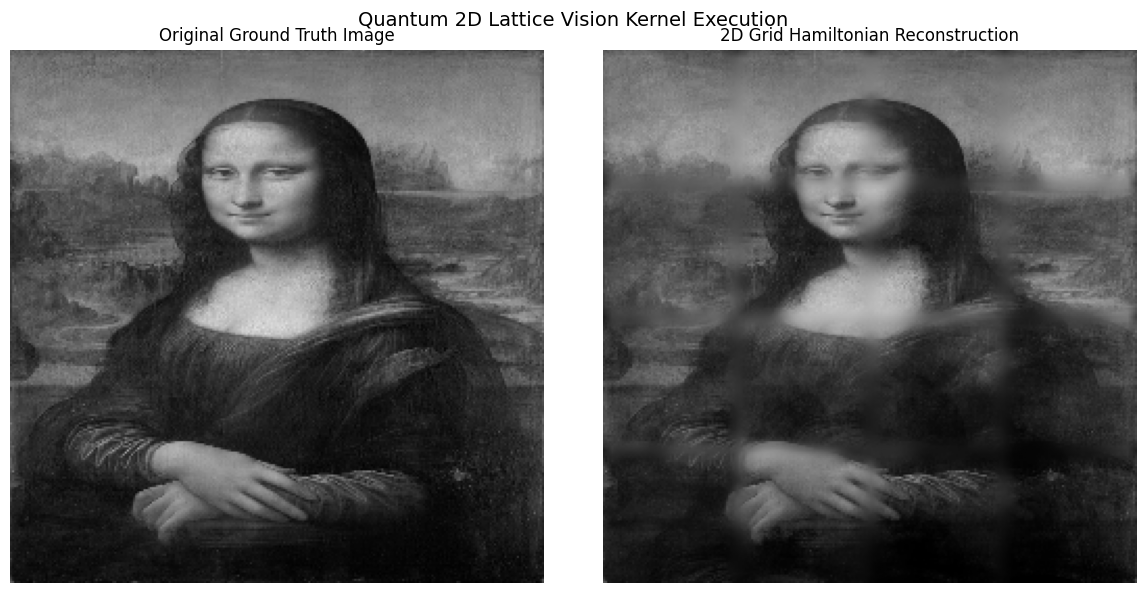

In [ ]:
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import quimb.tensor as qtn
import pennylane as qml
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img = cv2.imread("/home/adminpc/Desktop/HVK/Script/Hamiltonian_Vision_Kernel/Main/data/monalisa.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256)).astype("float32") / 255.0


patch_size = 64
patches, positions_list = [], []

for i in range(0, 256, patch_size):
    for j in range(0, 256, patch_size):
        patches.append(img[i:i+patch_size, j:j+patch_size])
        positions_list.append([i / 256.0, j / 256.0])

patches = np.array(patches)
positions_np = np.array(positions_list, dtype=np.float32)

positions = torch.tensor(positions_np, dtype=torch.float32).to(device)
target = torch.tensor(patches, dtype=torch.float32).unsqueeze(1).to(device)

n_sites = 12
bond_dim = 4
Z_op = np.array([[1,  0], [0, -1]], dtype=complex)
X_op = np.array([[0,  1], [1,  0]], dtype=complex)

def local_expectation(mps, op, site):
    mps_c = mps.copy()
    mps_c.gate(op, site)
    return float((mps.H @ mps_c).real)

def extract_mps_features(patch: np.ndarray) -> np.ndarray:
    v = patch.flatten()
    v = v / (np.linalg.norm(v) + 1e-8)
    psi = v.reshape([2] * n_sites)
    mps = qtn.MatrixProductState.from_dense(psi)
    mps.compress(max_bond=bond_dim)
    mps.normalize()
    
    feats = []
    for i in range(n_sites):
        feats.append(local_expectation(mps, Z_op, i))
        feats.append(local_expectation(mps, X_op, i))
    return np.array(feats, dtype=np.float32)

print("Extracting MPS features from image patches...")
features_list = [extract_mps_features(p) for p in patches]
features = torch.tensor(np.array(features_list), dtype=torch.float32)
features = (features - features.mean(dim=0)) / (features.std(dim=0) + 1e-8)
features = features.to(device)

FEATURE_DIM = features.shape[1] 
POS_ENC_DIM = 8

def sinusoidal_pos_enc(pos_np: np.ndarray, d_model: int = POS_ENC_DIM) -> torch.Tensor:
    N = len(pos_np)
    enc = np.zeros((N, d_model), dtype=np.float32)
    for k in range(d_model // 4):
        freq = 1.0 / (10000 ** (4 * k / d_model))
        enc[:, 4*k+0] = np.sin(pos_np[:, 0] * freq * np.pi)
        enc[:, 4*k+1] = np.cos(pos_np[:, 0] * freq * np.pi)
        enc[:, 4*k+2] = np.sin(pos_np[:, 1] * freq * np.pi)
        enc[:, 4*k+3] = np.cos(pos_np[:, 1] * freq * np.pi)
    return torch.tensor(enc, dtype=torch.float32).to(device)

pos_enc = sinusoidal_pos_enc(positions_np)
n_qubits = 6

edges_h = [(0, 1), (1, 2), (3, 4), (4, 5)] 
edges_v = [(0, 3), (1, 4), (2, 5)]          
all_edges = edges_h + edges_v               

OBS_DIM = n_qubits + n_qubits + len(all_edges) # Z (6) + X (6) + 2D ZZ Correlations (7) = 19
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_grid_circuit(x, pos_angles, weights):
    # Angle embedding for compressed patch features
    qml.AngleEmbedding(x, wires=range(n_qubits))
    
    # Spatially-aware positional rotations
    for i in range(n_qubits):
        qml.RY(pos_angles[i], wires=i)

    # Entangling blocks matching 2D physical grid fabric
    for l in range(weights.shape[0]):
        for u, v in edges_h: qml.CNOT(wires=[u, v])
        for u, v in edges_v: qml.CNOT(wires=[u, v])
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)

    return (
        [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)] +
        [qml.expval(qml.PauliX(i)) for i in range(n_qubits)] +
        [qml.expval(qml.PauliZ(u) @ qml.PauliZ(v)) for u, v in all_edges]
    )

############################################
# 4. QUANTUM MODEL WITH 2D HAMILTONIAN LOSS
############################################
class Quantum2DGridModel(nn.Module):
    def __init__(self, feature_dim: int):
        super().__init__()
        self.proj = nn.Linear(feature_dim, n_qubits)
        self.pos_proj = nn.Linear(POS_ENC_DIM, n_qubits)
        self.weights = nn.Parameter(torch.rand(2, n_qubits, 3) * float(np.pi))
        
        # Learnable 2D grid coupling weights for our 7 active bonds
        self.J_2d = nn.Parameter(0.1 * torch.randn(len(all_edges)))

    def forward(self, features, pos_encodings):
        vectors = self.proj(features)
        pos_angles = self.pos_proj(pos_encodings)
        all_obs, energies = [], []
        
        for v, pa in zip(vectors, pos_angles):
            out = torch.stack(quantum_grid_circuit(v, pa, self.weights))
            
            # Extract 2D grid ZZ expectation values
            zz_2d = out[2*n_qubits:]
            all_obs.append(out)
            
            # Calculating the 2D Hamiltonian Energy Configuration
            energy = torch.sum(self.J_2d * zz_2d)
            energies.append(energy)
            
        all_obs = torch.stack(all_obs).float()
        energies = torch.stack(energies).float()
        
        if self.training:
            all_obs = all_obs + 0.01 * torch.randn_like(all_obs)
        return all_obs, energies
    
DECODER_IN = OBS_DIM + POS_ENC_DIM
class PatchDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(DECODER_IN, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, patch_size * patch_size),
            nn.Sigmoid()
        )
    def forward(self, obs, pos):
        x = torch.cat([obs, pos], dim=-1)
        return self.net(x).view(-1, 1, patch_size, patch_size)

def stitch(patch_arr: np.ndarray) -> np.ndarray:
    out = np.zeros((256, 256), dtype=np.float32)
    idx = 0
    for i in range(0, 256, patch_size):
        for j in range(0, 256, patch_size):
            out[i:i+patch_size, j:j+patch_size] = patch_arr[idx, 0]
            idx += 1
    return out

def blend_seams(img_in: np.ndarray, patch_size: int = 64, blend_width: int = 8) -> np.ndarray:
    original = img_in.copy()
    weight = np.ones((256, 256), dtype=np.float32)
    for seam in range(patch_size, 256, patch_size):
        for d in range(blend_width):
            alpha = d / blend_width
            for pos in [seam - d, seam + d]:
                if 0 <= pos < 256:
                    weight[pos, :] = np.minimum(weight[pos, :], alpha)
                    weight[:, pos] = np.minimum(weight[:, pos], alpha)
    k = np.ones(9, dtype=np.float32) / 9.0
    blurred = np.apply_along_axis(lambda r: np.convolve(r, k, mode='same'), 1,
               np.apply_along_axis(lambda c: np.convolve(c, k, mode='same'), 0, original))
    return np.clip(weight * original + (1.0 - weight) * blurred, 0.0, 1.0)
model = Quantum2DGridModel(feature_dim=FEATURE_DIM).to(device)
decoder = PatchDecoder().to(device)
optimizer = optim.Adam(list(model.parameters()) + list(decoder.parameters()), lr=0.004)

print("Starting training optimization using 2D Grid Hamiltonian Loss...")
for step in range(121):
    model.train()
    optimizer.zero_grad()
    
    obs, energy = model(features, pos_enc)
    output = decoder(obs, pos_enc)
    
    rec_loss = torch.mean((output - target) ** 2)
    energy_loss = torch.mean(energy) # 2D Ground state tracking
    
    # Combined Loss: Vision Accuracy + Quantum 2D Physical Stability Constraint
    loss = rec_loss + 0.01 * energy_loss
    
    loss.backward()
    optimizer.step()
    
    if step % 20 == 0:
        print(f"Step: {step:>4d} | Total Loss: {loss.item():.6f} | Reconstruction MSE: {rec_loss.item():.6f} | 2D Energy: {energy_loss.item():.6f}")

############################################
# 7. INFERENCE & VISUAL RECONSTRUCTION
############################################
model.eval()
with torch.no_grad():
    obs, _ = model(features, pos_enc)
    pred_patches = decoder(obs, pos_enc).cpu().numpy()
    img_rec_raw = stitch(pred_patches)
    img_rec_final = blend_seams(img_rec_raw)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original Ground Truth Image", fontsize=12)
axes[0].axis("off")

axes[1].imshow(img_rec_final, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("2D Grid Hamiltonian Reconstruction", fontsize=12)
axes[1].axis("off")

plt.suptitle("Quantum 2D Lattice Vision Kernel Execution", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

Extracting MPS states...
Optimizing critical ground state pathways...
Simulating phase transition spectrum frames...
Compiling video tracks...
Success! Video rendered and saved as: 'quantum_phase_transition.mp4'


In [7]:
!pip install qutip 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 1.9 MB/s  0:00:15m0:00:0100:01m

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


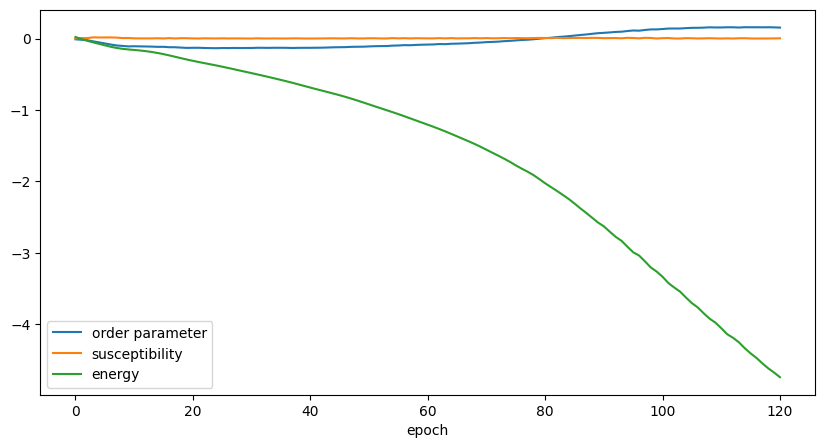

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/adminpc/Desktop/HVK/Script/Hamiltonian_Vision_Kernel/Main2/Scripts/hvk_epoch_reconstruction_table.csv")
plt.figure(figsize=(10,5))
plt.plot(df.epoch, df.mean_order_parameter, label="order parameter")
plt.plot(df.epoch, df.order_parameter_susceptibility, label="susceptibility")
plt.plot(df.epoch, df.mean_energy, label="energy")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [4]:
import cv2

img_path = "/home/adminpc/Desktop/HVK/Script/Hamiltonian_Vision_Kernel/Main/data/monalisa.jpg"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256)).astype("float32") / 255.0

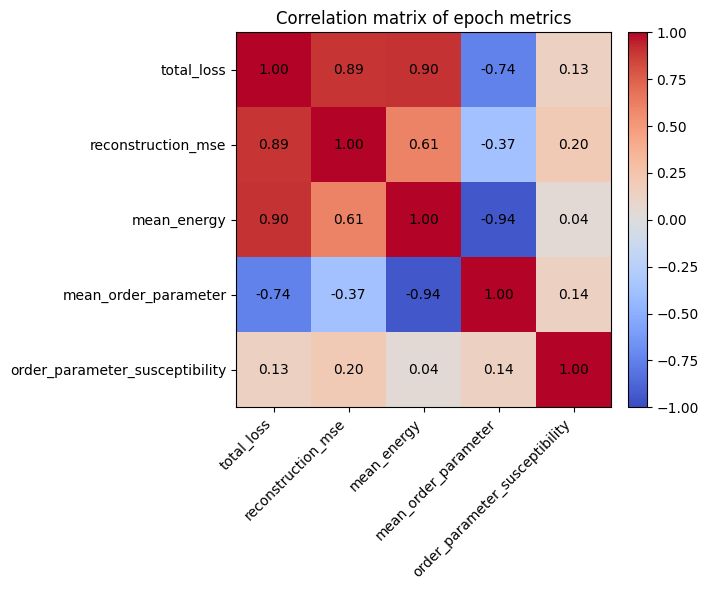

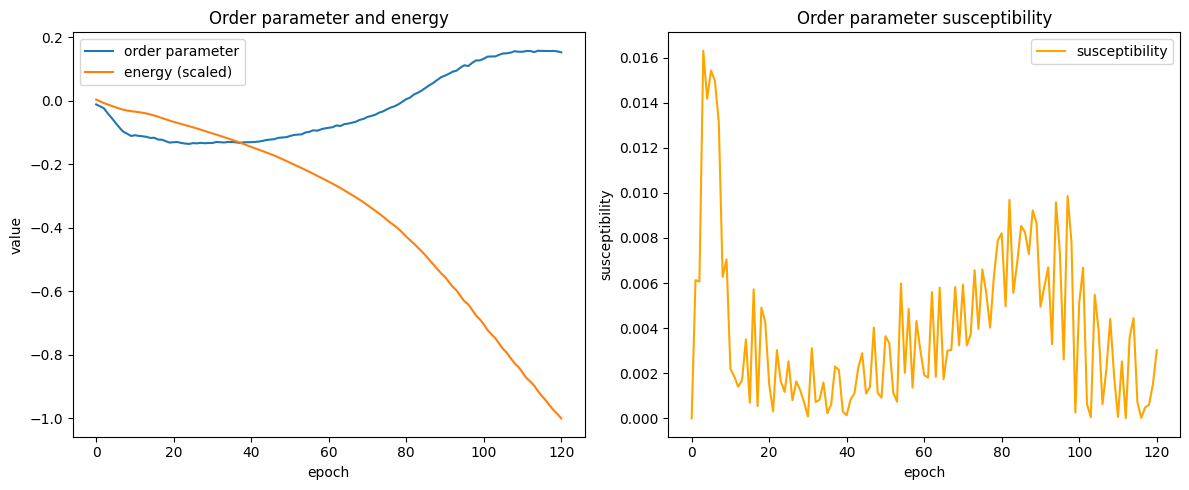

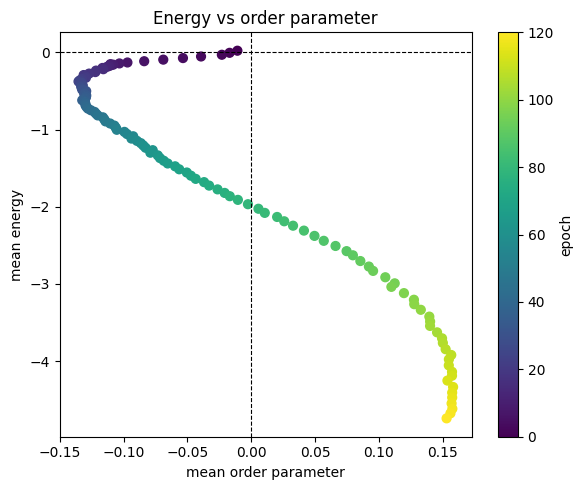

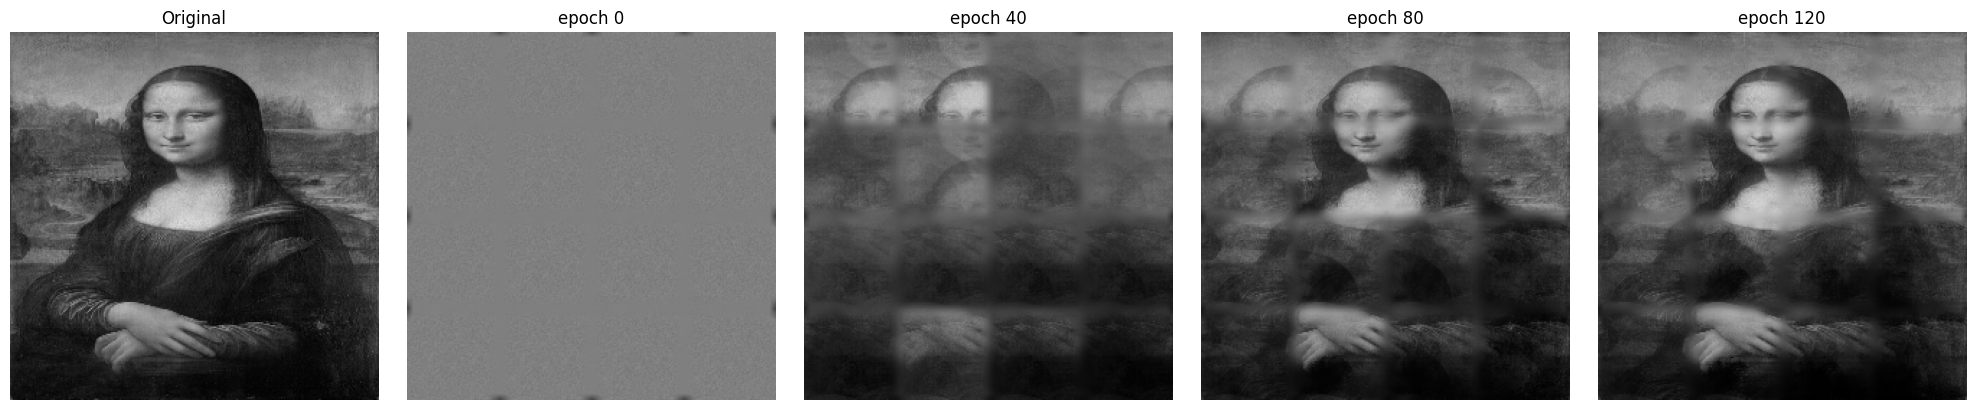

Run the reconstruction cell first to populate img_rec_final.


In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/home/adminpc/Desktop/HVK/Script/Hamiltonian_Vision_Kernel/Main2/Scripts/hvk_epoch_reconstruction_table.csv"
frame_dir = "/home/adminpc/Desktop/HVK/Script/Hamiltonian_Vision_Kernel/Main2/Scripts/phase_transition_frames"

with open(csv_path, newline="") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

epochs = np.array([int(r["epoch"]) for r in rows])
total_loss = np.array([float(r["total_loss"]) for r in rows])
reconstruction_mse = np.array([float(r["reconstruction_mse"]) for r in rows])
mean_energy = np.array([float(r["mean_energy"]) for r in rows])
mean_order_parameter = np.array([float(r["mean_order_parameter"]) for r in rows])
order_parameter_susceptibility = np.array([float(r["order_parameter_susceptibility"]) for r in rows])

# Correlation matrix plot
labels = [
    "total_loss",
    "reconstruction_mse",
    "mean_energy",
    "mean_order_parameter",
    "order_parameter_susceptibility",
]
data = np.vstack(
    [total_loss, reconstruction_mse, mean_energy, mean_order_parameter, order_parameter_susceptibility]
)
corr = np.corrcoef(data)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation matrix of epoch metrics")
plt.tight_layout()
plt.show()

# Combined order parameter / energy plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(epochs, mean_order_parameter, label="order parameter")
axes[0].plot(epochs, mean_energy / np.abs(mean_energy).max(), label="energy (scaled)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("value")
axes[0].set_title("Order parameter and energy")
axes[0].legend()
axes[1].plot(epochs, order_parameter_susceptibility, color="orange", label="susceptibility")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("susceptibility")
axes[1].set_title("Order parameter susceptibility")
axes[1].legend()
plt.tight_layout()
plt.show()

# Scatter plot energy vs order parameter
plt.figure(figsize=(6, 5))
plt.scatter(mean_order_parameter, mean_energy, c=epochs, cmap="viridis", s=40)
plt.colorbar(label="epoch")
plt.xlabel("mean order parameter")
plt.ylabel("mean energy")
plt.title("Energy vs order parameter")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

# Reconstruction frame comparison
selected_epochs = [0, 40, 80, 120]
fig, axes = plt.subplots(1, len(selected_epochs) + 1, figsize=(4 * (len(selected_epochs) + 1), 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, e in zip(axes[1:], selected_epochs):
    epoch_path = os.path.join(frame_dir, f"epoch_{e:04d}.png")
    if os.path.exists(epoch_path):
        frame = plt.imread(epoch_path)
        ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"epoch {e}")
    else:
        ax.text(0.5, 0.5, f"missing\n{e}", ha="center", va="center", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Final reconstruction comparison
if "img_rec_final" in globals():
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title("Original Image")
    ax[0].axis("off")
    ax[1].imshow(img_rec_final, cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("Final Reconstruction")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()